## Main Goal


### Neste desafio, você vai construir um modelo de machine learning capaz de prever o valor do aluguel de um imóvel com base em suas características.


## EDA


In [37]:
# Import libs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Data/dataset_aluguel.csv')
df.head(10)

,id,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel
0,1,106.181018,1,36.760806,0,True,False,1767.122088
1,2,192.607146,4,10.453581,1,True,False,3278.742397
2,3,159.799091,5,27.072399,1,True,False,2953.899737
3,4,139.798773,4,34.789220,1,False,True,2514.717108
4,5,73.402796,5,11.427501,0,False,True,1942.164396
5,6,73.399178,5,8.747746,1,True,False,2141.303241
6,7,58.712542,3,49.108417,1,True,False,1625.680981
7,8,179.926422,5,25.831795,0,False,True,2854.591908
8,9,140.167252,4,13.041459,1,True,False,2702.673542
9,10,156.210887,5,49.812685,1,False,False,2456.538289


In [22]:
df.info() # Check data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     100 non-null    int64  
 1   tamanho_m2             100 non-null    float64
 2   n_quartos              100 non-null    int64  
 3   idade_casa             100 non-null    float64
 4   garagem                100 non-null    int64  
 5   localizacao_Periferia  100 non-null    bool   
 6   localizacao_Subúrbio   100 non-null    bool   
 7   valor_aluguel          100 non-null    float64
dtypes: bool(2), float64(3), int64(3)
memory usage: 5.0 KB


In [23]:
# Importante information
df.describe()

,id,tamanho_m2,n_quartos,idade_casa,garagem,valor_aluguel
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,120.527112,2.910000,25.794810,0.520000,2112.819084
std,29.011492,44.623412,1.400541,14.348628,0.502117,514.314100
min,1.000000,50.828318,1.000000,0.259243,0.000000,1192.728727
25%,25.750000,78.980114,1.750000,13.969405,0.000000,1694.633091
50%,50.500000,119.621368,3.000000,24.827177,1.000000,2069.395680
75%,75.250000,159.530468,4.000000,37.252879,1.000000,2520.182679
max,100.000000,198.033040,5.000000,49.812685,1.000000,3278.742397


In [24]:
# Bools to 1 and 0
df['localizacao_Periferia'] = df['localizacao_Periferia'].apply(lambda x: 1 if x == 1 else 0)
df['localizacao_Subúrbio'] = df['localizacao_Subúrbio'].apply(lambda x: 1 if x == 1 else 0)
df.drop(columns=['id'], inplace=True)

df.head()

,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel
0,106.181018,1,36.760806,0,1,0,1767.122088
1,192.607146,4,10.453581,1,1,0,3278.742397
2,159.799091,5,27.072399,1,1,0,2953.899737
3,139.798773,4,34.789220,1,0,1,2514.717108
4,73.402796,5,11.427501,0,0,1,1942.164396


In [25]:
# Verify missing values
df.isnull().sum()

tamanho_m2               0
n_quartos                0
idade_casa               0
garagem                  0
localizacao_Periferia    0
localizacao_Subúrbio     0
valor_aluguel            0
dtype: int64

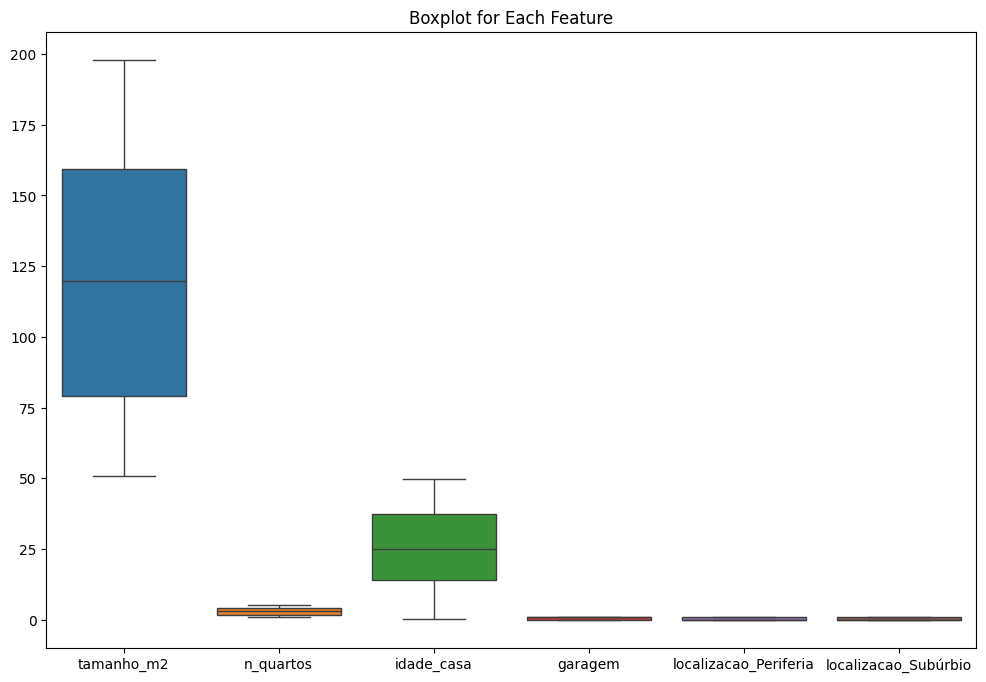

In [26]:
# Verify outliers
plt.figure(figsize=(12, 8))
df_boxplot = df.drop("valor_aluguel", axis=1)
sns.boxplot(data=df_boxplot)
plt.title('Boxplot for Each Feature')
plt.show()

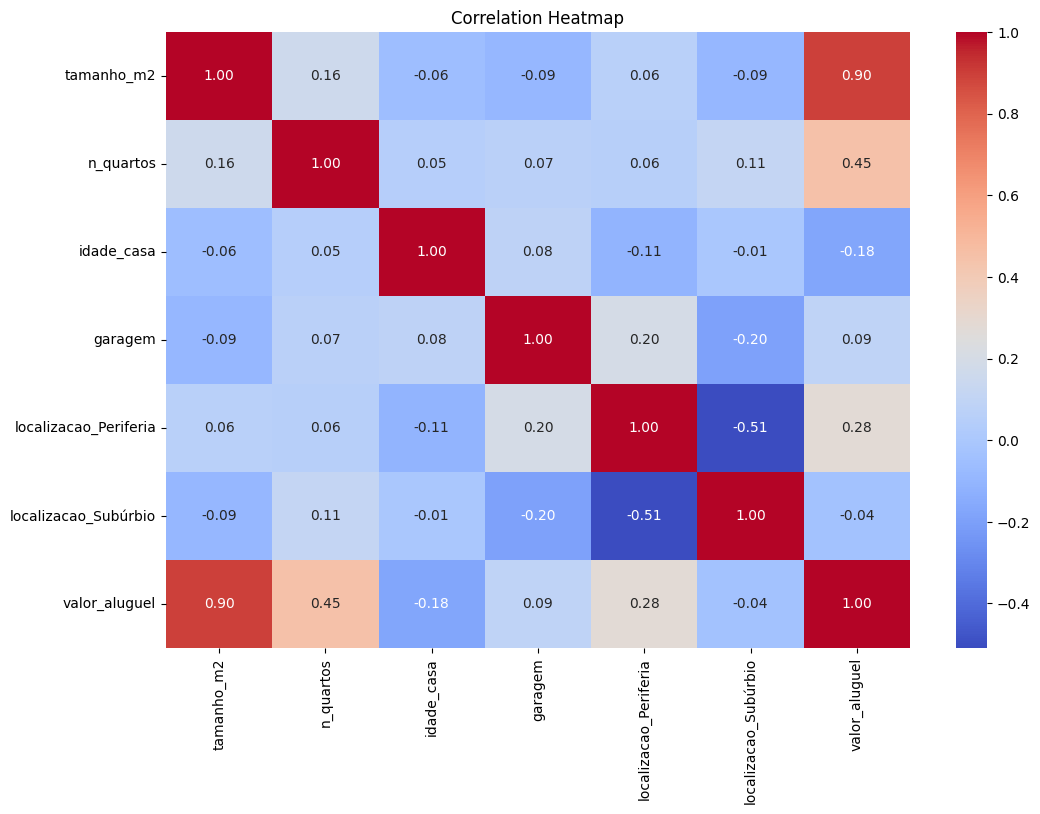

In [27]:
# Veirfy correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

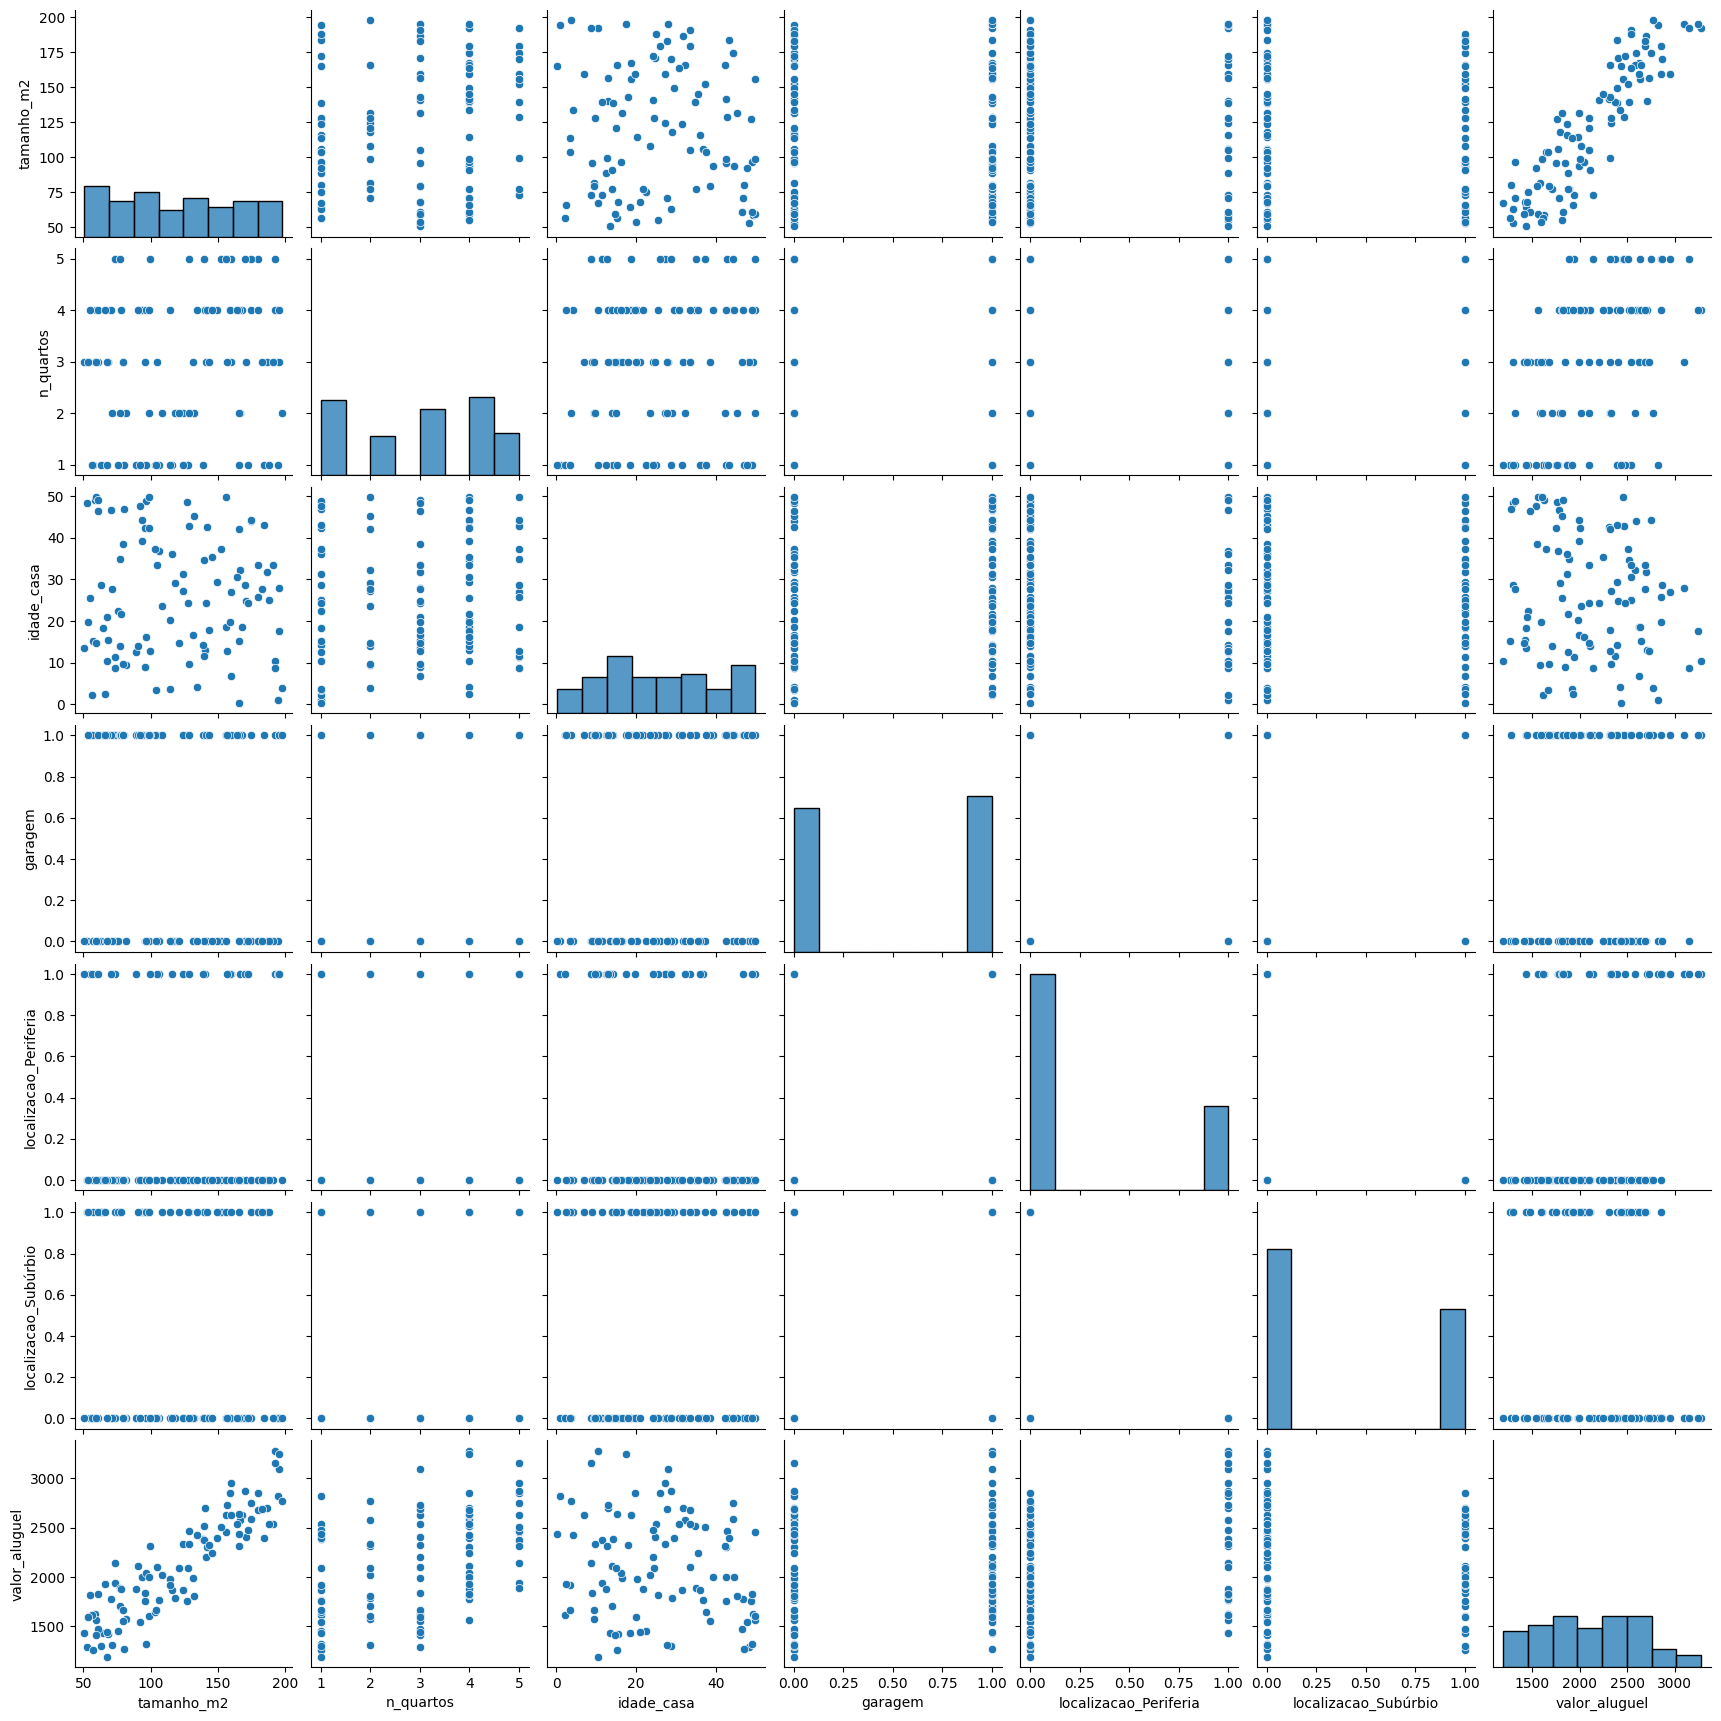

In [28]:
sns.pairplot(df)
plt.show()

In [29]:
# Statistical Pearson and Spearman Analysis

from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_p = pearsonr(df['tamanho_m2'], df['valor_aluguel'])
spearman_corr, spearman_p = spearmanr(df['tamanho_m2'], df['valor_aluguel'])
print(f'Pearson correlation: {pearson_corr}')
print(f'Spearman correlation: {spearman_corr}')

# p-value prints
print(f'Pearson p-value: {pearson_p}')
if pearson_p < 0.05:
    print("Pearson correlation is statistically significant.")
print(f'Spearman p-value: {spearman_p}') 
if spearman_p < 0.05:
    print("Spearman correlation is statistically significant.")   



Pearson correlation: 0.8963535167501041
Spearman correlation: 0.8875967596759675
Pearson p-value: 2.1473528447112404e-36
Pearson correlation is statistically significant.
Spearman p-value: 9.195092088149903e-35
Spearman correlation is statistically significant.


## Model Train (Linear Regression)

In [30]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

In [31]:
# Splitting Data

X = df.drop('valor_aluguel', axis=1)
y = df['valor_aluguel']

Kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Transformer
columns = X.columns

transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', transformer, columns)
    ]
)

model_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [32]:
# Training Model

r2score_list = []
mae_list = []
residuals_list = []
y_pred_tot = []
for train_index, test_index in Kfold.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_pipe.fit(X_train, y_train)

    y_pred = model_pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    r2score_list.append(r2)
    mae_list.append(mae)

    residual = y_test - y_pred
    residuals_list.append(residual)
    y_pred_tot.append(y_pred)

r2_final = np.mean(r2score_list)
mae_final = np.mean(mae_list)


print(f"Average R² Score: {r2_final:.4f}")
print(f"Average MAE: {mae_final:.4f}")
if r2_final > 0.7:
    print("The model has a good fit.")
else:
    print("The model may need improvement.")
if mae_final < y.mean() * 0.1:
    print("The model has acceptable error.")
else:
    print("The model error is high; consider further tuning.")

Average R² Score: 0.9909
Average MAE: 38.6043
The model has a good fit.
The model has acceptable error.


Text(0.5, 0, 'Actual Revenue')

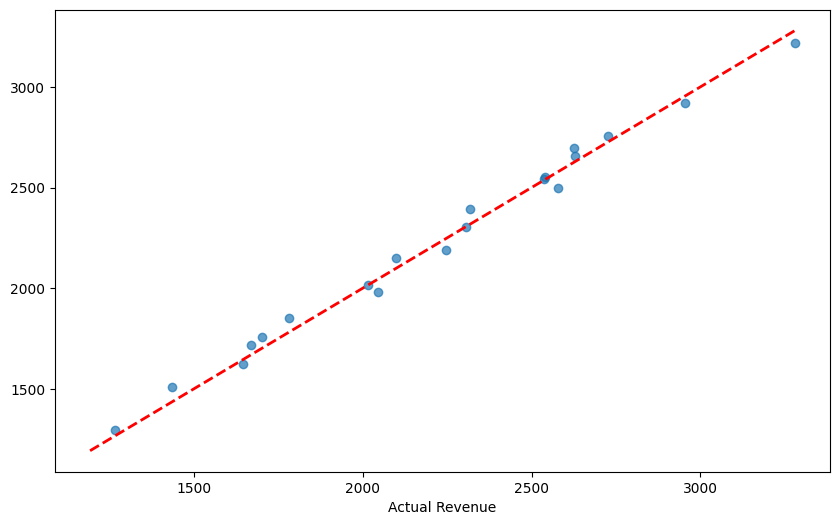

In [33]:
# Plotting a image of comparison between actual and predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Revenue')

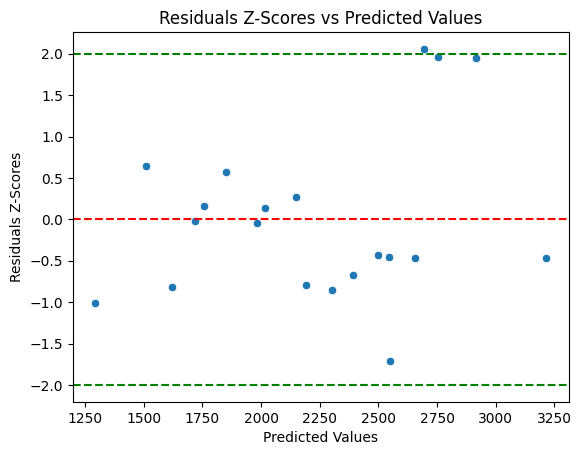

In [36]:
# Plotting residuals
from scipy.stats import zscore
residuals_std = zscore(residuals_list[0])

sns.scatterplot(x=y_pred, y=residuals_std)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(2, color='green', linestyle='--')
plt.axhline(-2, color='green', linestyle='--')
plt.title('Residuals Z-Scores vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals Z-Scores')
plt.show()

In [ ]:
from scipy.stats import shapiro, kstest
from statsmodels.stats.diagnostic import lilliefors

def interpret_normality_test(stat, p_value, test_name):
    alpha = 0.05
    if p_value > alpha:
        print(f"{test_name}: Statistic={stat:.4f}, p-value={p_value:.4f} -> Fail to reject H0 (Residuals are normally distributed)")
    else:
        print(f"{test_name}: Statistic={stat:.4f}, p-value={p_value:.4f} -> Reject H0 (Residuals are not normally distributed)")

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = shapiro(residuals)
interpret_normality_test(shapiro_stat, shapiro_p, "Shapiro-Wilk Test")

# Kolmogorov-Smirnov Test
ks_stat, ks_p = kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
interpret_normality_test(ks_stat, ks_p, "Kolmogorov-Smirnov Test")

# Lilliefors Test
lillie_stat, lillie_p = lilliefors(residuals)
interpret_normality_test(lillie_stat, lillie_p, "Lilliefors Test")

Shapiro-Wilk Test: Statistic=0.9281, p-value=0.1420 -> Fail to reject H0 (Residuals are normally distributed)
Kolmogorov-Smirnov Test: Statistic=0.1278, p-value=0.8595 -> Fail to reject H0 (Residuals are normally distributed)
Lilliefors Test: Statistic=0.1220, p-value=0.5957 -> Fail to reject H0 (Residuals are normally distributed)


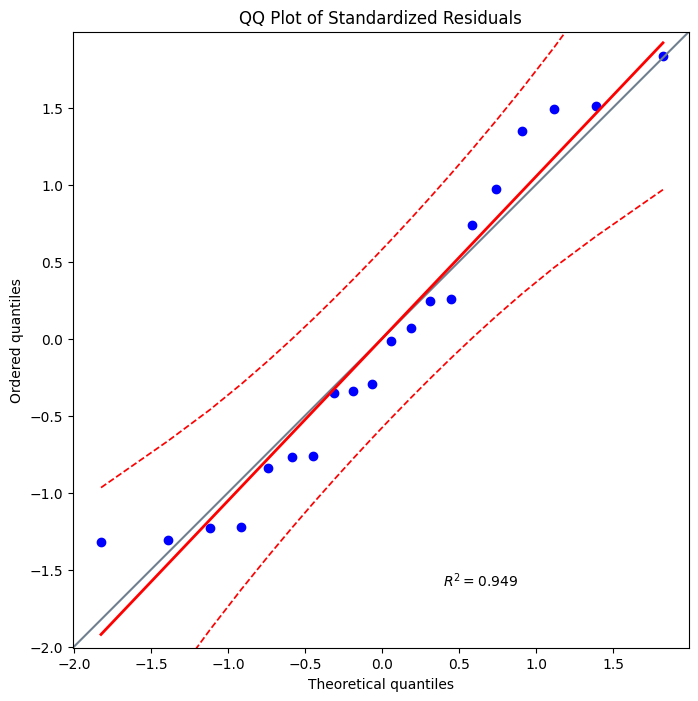

In [ ]:
# QQ Plot
import pingouin as pg
plt.figure(figsize=(14,8))
pg.qqplot(residuals_std, dist='norm', confidence=0.95)
plt.title('QQ Plot of Standardized Residuals')
plt.show()

## Multiple Linear Regression

In [38]:
# Multiple linear regression with polynomial features
# Preprocessing Data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold


Average R² Score: 0.9907
Average MAE: 39.0243
The model has a good fit.
The model has acceptable error.


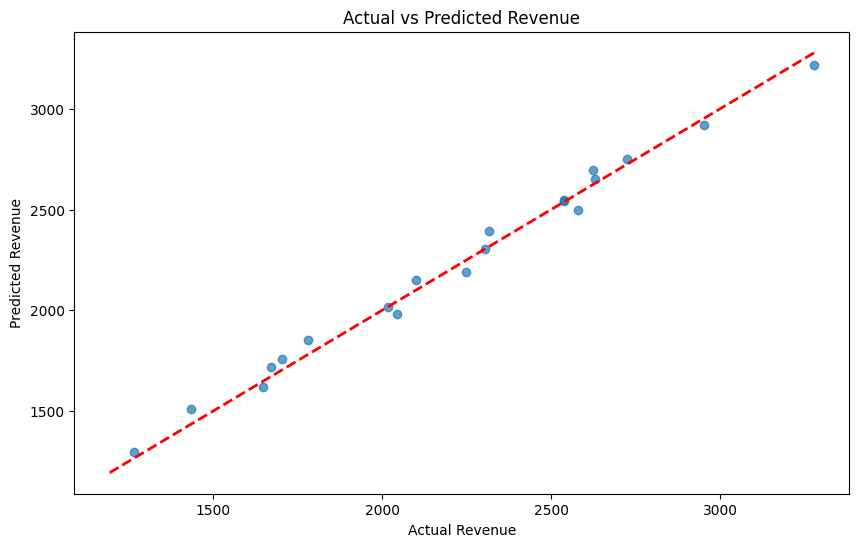

In [42]:
# Splitting Data
X = df.drop('valor_aluguel', axis=1)
y = df['valor_aluguel']

# Convert boolean columns to int to avoid SimpleImputer errors
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

Kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Transformers

# Ordinal features
ordinal_cols = ['localizacao_Periferia', 'localizacao_Subúrbio']
ordinal_cols = [col for col in ordinal_cols if col in X.columns]
ordinal_categories = [[0, 1] for _ in ordinal_cols]
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories))
])

# Numerical features
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col not in ordinal_cols]
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('ord', ordinal_transformer, ordinal_cols)
    ],
    remainder='drop'
 )

model_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Training Model

r2score_list = []
mae_list = []
residuals_list = []
y_pred_tot = []
for train_index, test_index in Kfold.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_pipe.fit(X_train, y_train)

    y_pred = model_pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    r2score_list.append(r2)
    mae_list.append(mae)

    residual = y_test - y_pred
    residuals_list.append(residual)
    y_pred_tot.append(y_pred)
r2_final = np.mean(r2score_list)
mae_final = np.mean(mae_list)
print(f"Average R² Score: {r2_final:.4f}")
print(f"Average MAE: {mae_final:.4f}")
if r2_final > 0.7:
    print("The model has a good fit.")
else:
    print("The model may need improvement.")
if mae_final < y.mean() * 0.1:
    print("The model has acceptable error.")
else:
    print("The model error is high; consider further tuning.")
# Plotting a image of comparison between actual and predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.show()

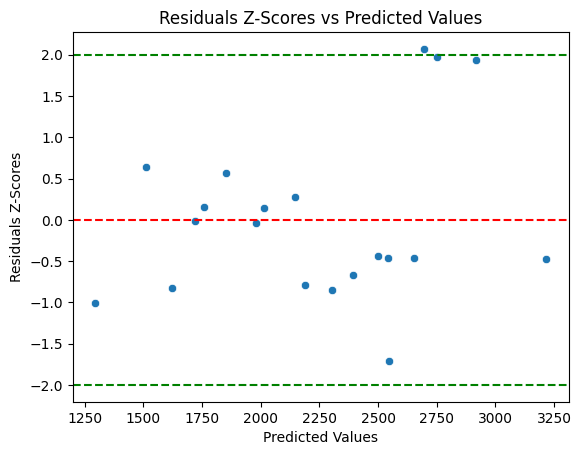

In [43]:
# Residuals plot
from scipy.stats import zscore
residuals_std = zscore(residuals_list[0])
sns.scatterplot(x=y_pred, y=residuals_std)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(2, color='green', linestyle='--')
plt.axhline(-2, color='green', linestyle='--')
plt.title('Residuals Z-Scores vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals Z-Scores')
plt.show()